In [12]:
import dataset, features, modeling, plots
import pandas as pd

Loaded merged data with 8 price fields


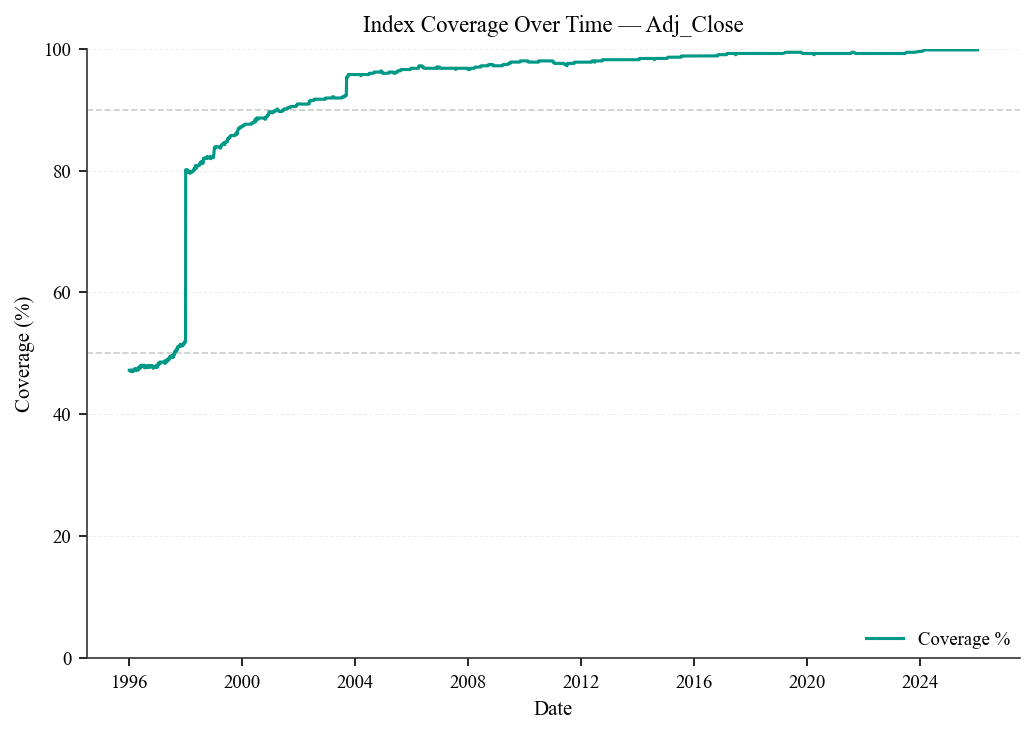

Missing ticker coverage periods:
- AAL:
  missing from 1996-01-02 to 1997-01-13
- AAMRQ:
  missing from 1996-01-02 to 2003-03-10
- ABI:
  missing from 1996-01-02 to 1997-12-29
  missing from 2008-11-18 to 2008-11-20
- ABKFQ:
  missing from 2000-12-11 to 2008-06-10
- ABS:
  missing from 1996-01-02 to 1997-12-29
- ABX:
  missing from 1996-01-02 to 2002-07-18
- ACKH:
  missing from 1996-01-02 to 1997-12-29
- ACV:
  missing from 1996-01-02 to 2006-11-16
- ADCT:
  missing from 1999-08-02 to 2003-09-08
  missing from 2005-05-13 to 2005-06-06
- AET:
  missing from 1996-01-02 to 1997-12-29
- AFS.A:
  missing from 1998-04-08 to 2000-11-29
- AGC:
  missing from 1996-01-02 to 2001-03-22
- AHM:
  missing from 1996-01-02 to 1997-12-29
- AL:
  missing from 1996-01-02 to 2002-07-18
- AM:
  missing from 1996-01-02 to 1997-12-29
- AMH:
  missing from 1996-01-02 to 1997-09-08
- AMP:
  missing from 1996-01-02 to 1999-03-30
- ANDW:
  missing from 1996-01-02 to 1997-12-29
- ANRZQ:
  missing from 2011-06-02

In [13]:
sp500_components: pd.DataFrame = dataset.SP500.load_historical()
merged_data: dict[str, pd.DataFrame] = features.load_merged_data()
coverage: pd.DataFrame = plots.coverage_over_time(
    price_data=merged_data,
    components=sp500_components,
    save_figures=False
)
missing_tickers: pd.DataFrame = pd.read_csv("../data/processed/missing_ticker.csv", index_col=0, parse_dates=True)
benchmark_df: pd.DataFrame = pd.read_csv("../data/processed/benchmark_2026-06-01.csv", index_col=0, parse_dates=True)
N = 15

# Tworzenie strategii

Przy doborze portfeli inwestycyjnych jednym z kluczowych parametrów jest **liczba spółek wchodzących** w ich skład. Liczba ta może być zmienna — co często występuje w portfelach aktywnie zarządzanych — lub stała, co jest typowe dla portfeli dobieranych automatycznie według określonych reguł.

Za optymalną równowagę pomiędzy dywersyfikacją a koncentracją portfela uznaje się zazwyczaj od 10 do 20 spółek. Zbyt duża liczba walorów może prowadzić do osiągania stóp zwrotu zbliżonych do indeksu rynkowego, a często nawet niższych. Z kolei nadmierna specjalizacja powoduje, że wyniki pojedynczych spółek mają zbyt duży wpływ na wartość całego portfela, zwiększając jego ryzyko.

W dalszej części pracy, przy analizie poszczególnych strategii, przyjęto środkową wartość tego przedziału, czyli portfel składający się z `N` = 15 spółek.

Kolejnym analizowanym parametrem jest **częstotliwość doboru** portfela, rozpatrywana w wariantach miesięcznym, kwartalnym oraz rocznym. Każda z tych częstotliwości wiąże się z inną równowagą pomiędzy szybkością reakcji na zmiany rynkowe a kosztami oraz stabilnością portfela. W ramach pracy przeprowadzone zostaną testy dla każdego z rozważanych wariantów.

Należy zaznaczyć również, że rzeczywiste stopy zwrotu byłyby niższe, szczególnie dla comiesięcznego doboru ze względu na koszty zmiany składu portfela.

Ekstremalne dzienne zwroty są odrzucane dla obu strategii, gdyż są one spowodowane błędami w zbiorze danych.

## Strategia losowa

Najprostszą strategią, którą można przetestować jest strategia losowa, która losowo dobiera daną liczbę spółek cyklicznie.

In [14]:
modeling.select_random(sp500_components, n=N, coverage=coverage, date="2001-01-01")

{'tickers': ['NWL',
  'BCR',
  'ADI',
  'RF',
  'DG',
  'CSX',
  'CNXT',
  'BMET',
  'RDC',
  'BAX',
  'PD',
  'UNM',
  'MBI',
  'AVY',
  'MTG'],
 'difference': 2}

In [15]:
random_M = modeling.select_random_periodic(
    components=sp500_components,
    n=N,
    start_date="2001-01-01",
    frequency="monthly",
    coverage=coverage
)
plots.summarize_df(random_M)
random_Q = modeling.select_random_periodic(
    components=sp500_components,
    n=N, 
    start_date="2001-01-01",
    frequency="quarterly",
    coverage=coverage
)
plots.summarize_df(random_Q)
random_Y = modeling.select_random_periodic(
    components=sp500_components,
    n=N,
    start_date="2001-01-01",
    frequency="yearly",
    coverage=coverage
)
plots.summarize_df(random_Y)

DataFrame summary:
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        301 non-null    datetime64[us]
 1   tickers     301 non-null    object        
 2   difference  301 non-null    int64         
dtypes: datetime64[us](1), int64(1), object(1)
memory usage: 7.2+ KB
None


,date,difference
count,301,301.00000000
mean,2013-07-01 13:28:30.299003,0.21926910
min,2001-01-01 00:00:00,0.00000000
25%,2007-04-01 00:00:00,0.00000000
50%,2013-07-01 00:00:00,0.00000000
75%,2019-10-01 00:00:00,0.00000000
max,2026-01-01 00:00:00,2.00000000
std,NaN,0.45287319


DataFrame summary:
<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        101 non-null    datetime64[us]
 1   tickers     101 non-null    object        
 2   difference  101 non-null    int64         
dtypes: datetime64[us](1), int64(1), object(1)
memory usage: 2.5+ KB
None


,date,difference
count,101,101.00000000
mean,2013-07-01 11:38:36.831683,0.21782178
min,2001-01-01 00:00:00,0.00000000
25%,2007-04-01 00:00:00,0.00000000
50%,2013-07-01 00:00:00,0.00000000
75%,2019-10-01 00:00:00,0.00000000
max,2026-01-01 00:00:00,2.00000000
std,NaN,0.43826842


DataFrame summary:
<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        26 non-null     datetime64[us]
 1   tickers     26 non-null     object        
 2   difference  26 non-null     int64         
dtypes: datetime64[us](1), int64(1), object(1)
memory usage: 756.0+ bytes
None


,date,difference
count,26,26.00000000
mean,2013-07-02 06:27:41.538461,0.26923077
min,2001-01-01 00:00:00,0.00000000
25%,2007-04-02 06:00:00,0.00000000
50%,2013-07-02 12:00:00,0.00000000
75%,2019-10-01 18:00:00,0.00000000
max,2026-01-01 00:00:00,2.00000000
std,NaN,0.53349357


,date,tickers,difference
0,2001-01-01,"[NWL, BCR, ADI, RF, DG, CSX, CNXT, BMET, RDC, ...",2
1,2002-01-01,"[HNZ, ADSK, ADP, AWE, CNP, CPNLQ, KMI, MTG, AD...",1
24,2025-01-01,"[CME, KR, HRL, BX, HAL, CINF, DOW, IBM, DAY, T...",0
25,2026-01-01,"[TKO, LIN, AZO, AMCR, NKE, LDOS, T, ADBE, XOM,...",0


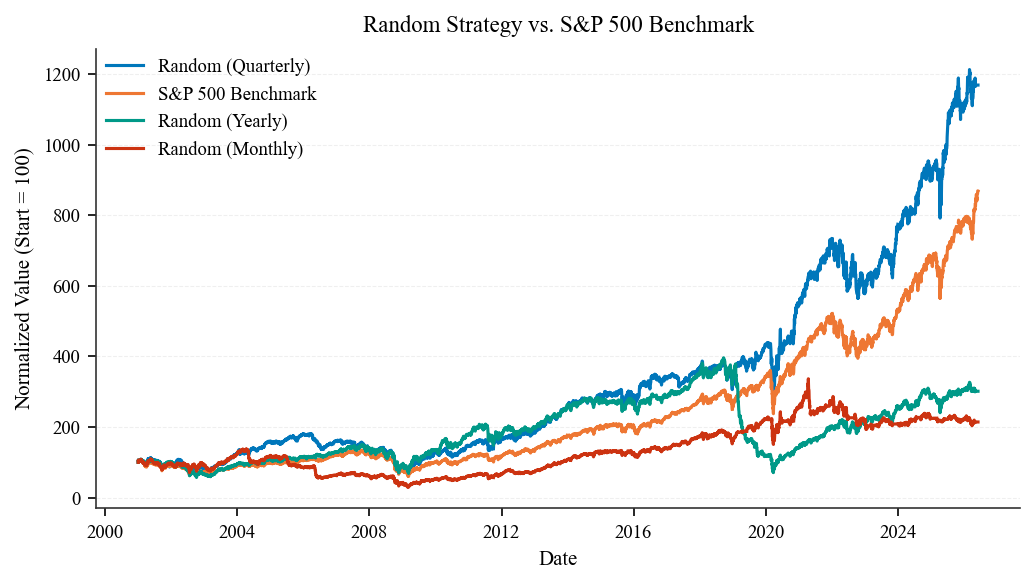

,Random (Quarterly),S&P 500 Benchmark,Random (Yearly),Random (Monthly)
Date,,,,
2001-01-02,100.00000000,100.00000000,100.00000000,100.00000000
2001-01-03,106.38738469,105.02142209,106.38738469,106.38738469
2001-01-04,104.20752684,103.91472269,104.20752684,104.20752684
2001-01-05,100.81902244,101.18705757,100.81902244,100.81902244
2001-01-08,101.52242406,101.01272056,101.52242406,101.52242406
...,...,...,...,...
2026-05-26,1168.41105849,859.98629693,301.06165078,214.02438992
2026-05-27,1168.41105849,860.09273034,301.06165078,214.02438992
2026-05-28,1168.41105849,864.91236499,301.06165078,214.02438992


In [ ]:
portfolio_random_M = modeling.backtest_portfolio(
    selected_companies=random_M, 
    price_data=merged_data,
    start_date="2001-01-01",
    coverage=coverage,
    missing_ticker=missing_tickers,
    max_abs_return=2.0,
)
portfolio_random_Q = modeling.backtest_portfolio(
    selected_companies=random_Q, 
    price_data=merged_data,
    start_date="2001-01-01",
    coverage=coverage,
    missing_ticker=missing_tickers,
    max_abs_return=2.0,
)
portfolio_random_Y = modeling.backtest_portfolio(
    selected_companies=random_Y, 
    price_data=merged_data,
    start_date="2001-01-01",
    coverage=coverage,
    missing_ticker=missing_tickers,
    max_abs_return=2.0,
)

plots.YahooFinance.compare_tickers(
    dfs={
        "Random (Monthly)": portfolio_random_M,
        "Random (Quarterly)": portfolio_random_Q,
        "Random (Yearly)": portfolio_random_Y,
        "Benchmark": benchmark_df
    },
    title="Random Strategy vs. S&P 500 Benchmark",
    filename="24-random-strategy.png",
)

Można zauważyć, że strategia losowa dla częstszego doboru radzi sobie wyraźnie gorzej dla doboru miesięcznego i rocznego od benchmarku. Dla doboru kwartalnego - wyraźnie lepiej, co budzi wątpliwości co do jakości zbioru danych.

## Strategia Monte Carlo

W przypadku metody Monte Carlo dochodzi kolejny czynnik - **okno wstecz**, które przyjąłem za rok, a więc w przybliżeniu 252 dni handlowych.

W poniższej strategii Monte Carlo to losowanie wielu portfeli, a nie symulacja ścieżek cen dla pojedynczych spółek. Dla każdej daty rebalansu wybiera się aktywne spółki z indeksu i zostawia te z wystarczającą liczbą obserwacji w oknie wstecz.
Dla każdej spółki liczę średni dzienny zwrot i zmienność, po czym losuje się określoną liczbę portfeli (przyjęto: 500) po `N` spółek. Wybrany portfel to ten o najwyższym [**współczynniku Sharpe'a**](https://pl.wikipedia.org/wiki/Wska%C5%BAnik_Sharpe%E2%80%99a), obliczanym według wzoru:

$$\displaystyle S={\frac {\mu - r_{f}}{\sigma}}$$

gdzie:
- $S$ – współczynnik Sharpe’a,
- $\mu$ – średnia stopa zwrotu portfela w danym okresie,
- $r_f$ – średnia stopa zwrotu wolna od ryzyka w danym okresie,
- $\sigma$ – odchylenie standardowe stopy zwrotu portfela w danym okresie.

W tej pracy przyjmuję $r_f = 0$, ponieważ celem jest jedynie relatywne porównanie portfeli, co sprowadza wskaźnik do ilorazu średniego zwrotu i zmienności

In [17]:
mc_M = modeling.select_monte_carlo_periodic(
    components=sp500_components,
    price_data=merged_data,
    n=N,
    start_date="2001-01-01",
    frequency="monthly",
    lookback_days=252,
    n_trials=500,
    min_obs=60,
    max_abs_return=2.0,
    coverage=coverage,
)
plots.summarize_df(mc_M)
mc_Q = modeling.select_monte_carlo_periodic(
    components=sp500_components,
    price_data=merged_data,
    n=N,
    start_date="2001-01-01",
    frequency="quarterly",
    lookback_days=252,
    n_trials=500,
    min_obs=60,
    max_abs_return=2.0,
    coverage=coverage,
)
plots.summarize_df(mc_Q)
mc_Y = modeling.select_monte_carlo_periodic(
    components=sp500_components,
    price_data=merged_data,
    n=N,
    start_date="2001-01-01",
    frequency="yearly",
    lookback_days=252,
    n_trials=500,
    min_obs=60,
    max_abs_return=2.0,
    coverage=coverage,
)
plots.summarize_df(mc_Y)

DataFrame summary:
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          301 non-null    datetime64[us]
 1   tickers       301 non-null    object        
 2   difference    301 non-null    int64         
 3   sharpe_ratio  301 non-null    float64       
dtypes: datetime64[us](1), float64(1), int64(1), object(1)
memory usage: 9.5+ KB
None


,date,difference,sharpe_ratio
count,301,301.00000000,301.00000000
mean,2013-07-01 13:28:30.299003,0.21926910,0.07339933
min,2001-01-01 00:00:00,0.00000000,-0.02373405
25%,2007-04-01 00:00:00,0.00000000,0.05192544
50%,2013-07-01 00:00:00,0.00000000,0.07710736
75%,2019-10-01 00:00:00,0.00000000,0.09428597
max,2026-01-01 00:00:00,2.00000000,0.13608661
std,NaN,0.45287319,0.03023220


DataFrame summary:
<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          101 non-null    datetime64[us]
 1   tickers       101 non-null    object        
 2   difference    101 non-null    int64         
 3   sharpe_ratio  101 non-null    float64       
dtypes: datetime64[us](1), float64(1), int64(1), object(1)
memory usage: 3.3+ KB
None


,date,difference,sharpe_ratio
count,101,101.00000000,101.00000000
mean,2013-07-01 11:38:36.831683,0.21782178,0.07324144
min,2001-01-01 00:00:00,0.00000000,-0.00241686
25%,2007-04-01 00:00:00,0.00000000,0.05460289
50%,2013-07-01 00:00:00,0.00000000,0.07922169
75%,2019-10-01 00:00:00,0.00000000,0.09349766
max,2026-01-01 00:00:00,2.00000000,0.12740382
std,NaN,0.43826842,0.03132272


DataFrame summary:
<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          26 non-null     datetime64[us]
 1   tickers       26 non-null     object        
 2   difference    26 non-null     int64         
 3   sharpe_ratio  26 non-null     float64       
dtypes: datetime64[us](1), float64(1), int64(1), object(1)
memory usage: 964.0+ bytes
None


,date,difference,sharpe_ratio
count,26,26.00000000,26.00000000
mean,2013-07-02 06:27:41.538461,0.26923077,0.07468909
min,2001-01-01 00:00:00,0.00000000,-0.00335494
25%,2007-04-02 06:00:00,0.00000000,0.05759793
50%,2013-07-02 12:00:00,0.00000000,0.08145682
75%,2019-10-01 18:00:00,0.00000000,0.09615803
max,2026-01-01 00:00:00,2.00000000,0.11749838
std,NaN,0.53349357,0.03131669


,date,tickers,difference,sharpe_ratio
0,2001-01-01,"[WEN, CAH, NBR, COP, ED, SVU, PHM, AZO, STJ, A...",2,0.07556572
1,2002-01-01,"[ODP, CCL, HI, TGT, BAX, DLX, CCTYQ, MAT, BBT,...",1,0.05700331
24,2025-01-01,"[PSX, GLW, CHD, BKR, PEG, MA, PLTR, UNP, SYF, ...",0,0.10192171
25,2026-01-01,"[IBM, FCX, NEM, JBHT, KLAC, ANET, CPB, WRB, FF...",0,0.07338123


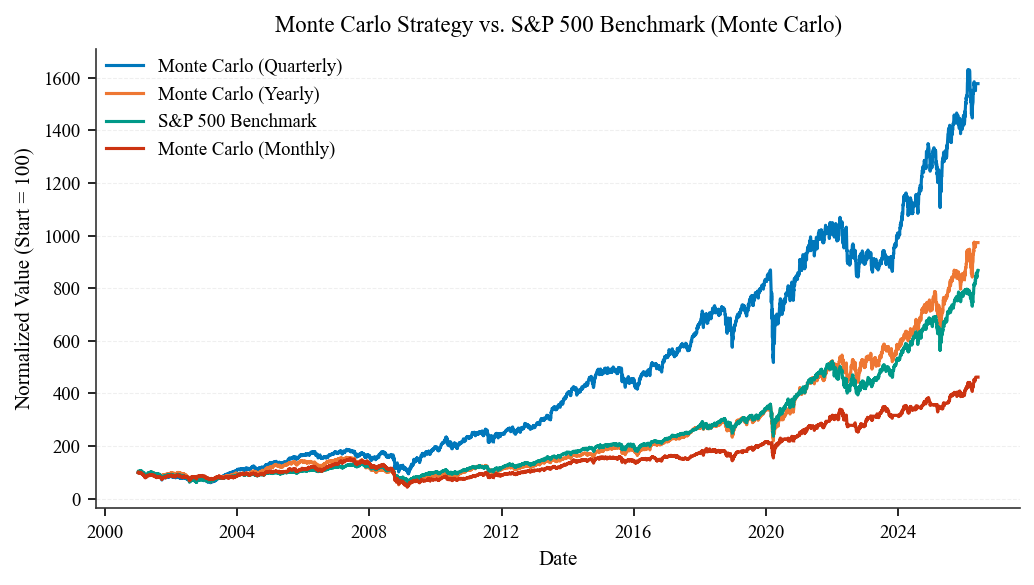

,Monte Carlo (Quarterly),Monte Carlo (Yearly),S&P 500 Benchmark,Monte Carlo (Monthly)
Date,,,,
2001-01-02,100.00000000,100.00000000,100.00000000,100.00000000
2001-01-03,102.08751784,102.08751784,105.02142209,102.08751784
2001-01-04,99.42945510,99.42945510,103.91472269,99.42945510
2001-01-05,97.58734245,97.58734245,101.18705757,97.58734245
2001-01-08,97.66898716,97.66898716,101.01272056,97.66898716
...,...,...,...,...
2026-05-26,1577.99730409,973.65273219,859.98629693,462.18847928
2026-05-27,1577.99730409,973.65273219,860.09273034,462.18847928
2026-05-28,1577.99730409,973.65273219,864.91236499,462.18847928


In [ ]:
portfolio_mc_M = modeling.backtest_portfolio(
    selected_companies=mc_M,
    price_data=merged_data,
    start_date="2001-01-01",
    coverage=coverage,
    missing_ticker=missing_tickers,
    max_abs_return=2.0,
)
portfolio_mc_Q = modeling.backtest_portfolio(
    selected_companies=mc_Q,
    price_data=merged_data,
    start_date="2001-01-01",
    coverage=coverage,
    missing_ticker=missing_tickers,
    max_abs_return=2.0,
)
portfolio_mc_Y = modeling.backtest_portfolio(
    selected_companies=mc_Y,
    price_data=merged_data,
    start_date="2001-01-01",
    coverage=coverage,
    missing_ticker=missing_tickers,
    max_abs_return=2.0,
)

plots.YahooFinance.compare_tickers(
    dfs={
        "Monte Carlo (Monthly)": portfolio_mc_M,
        "Monte Carlo (Quarterly)": portfolio_mc_Q,
        "Monte Carlo (Yearly)": portfolio_mc_Y,
        "Benchmark": benchmark_df
    },
    title="Monte Carlo Strategy vs. S&P 500 Benchmark (Monte Carlo)",
    filename="25-mc-strategy.png",
)

W przypadku strategii opartej na Monte Carlo również to dobór kwartalny daje najlepsze wyniki. Wynik zbliżony, ale lekko powyżej benchmarku osiąga dobór miesięczny, co jest dosyć zrozumiałe - to dosyć krótki okres dla inwestowania w akcje.

## Strategia najwyższego współczynnika Sharpe'a

W tej strategii, zamiast losować portfele, wybieramy `N` spółek, które w oknie wstecznym miały najwyższy indywidualny współczynnik Sharpe'a. A więc również nie jest to symulacja ścieżek cen dla pojedynczych spółek, a uproszczenie, które w teorii powinno dawać podobne wyniki. Jest to podejście bardziej deterministyczne, które faworyzuje historycznie "najlepsze" spółki niż losowanie portfeli. Parametry pozostają bez zmian.

In [19]:
bs_M = modeling.select_best_sharpe_periodic(
    components=sp500_components,
    price_data=merged_data,
    n=N,
    start_date="2001-01-01",
    frequency="monthly",
    lookback_days=252,
    min_obs=60,
    max_abs_return=2.0,
    coverage=coverage,
)
plots.summarize_df(bs_M)
bs_Q = modeling.select_best_sharpe_periodic(
    components=sp500_components,
    price_data=merged_data,
    n=N,
    start_date="2001-01-01",
    frequency="quarterly",
    lookback_days=252,
    min_obs=60,
    max_abs_return=2.0,
    coverage=coverage,
)
plots.summarize_df(bs_Q)
bs_Y = modeling.select_best_sharpe_periodic(
    components=sp500_components,
    price_data=merged_data,
    n=N,
    start_date="2001-01-01",
    frequency="yearly",
    lookback_days=252,
    min_obs=60,
    max_abs_return=2.0,
    coverage=coverage,
)
plots.summarize_df(bs_Y)

DataFrame summary:
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          301 non-null    datetime64[us]
 1   tickers       301 non-null    object        
 2   difference    301 non-null    int64         
 3   sharpe_ratio  301 non-null    float64       
dtypes: datetime64[us](1), float64(1), int64(1), object(1)
memory usage: 9.5+ KB
None


,date,difference,sharpe_ratio
count,301,301.00000000,301.00000000
mean,2013-07-01 13:28:30.299003,0.21926910,0.14238941
min,2001-01-01 00:00:00,0.00000000,0.02575698
25%,2007-04-01 00:00:00,0.00000000,0.12543433
50%,2013-07-01 00:00:00,0.00000000,0.14750098
75%,2019-10-01 00:00:00,0.00000000,0.16664692
max,2026-01-01 00:00:00,2.00000000,0.20870007
std,NaN,0.45287319,0.03584675


DataFrame summary:
<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          101 non-null    datetime64[us]
 1   tickers       101 non-null    object        
 2   difference    101 non-null    int64         
 3   sharpe_ratio  101 non-null    float64       
dtypes: datetime64[us](1), float64(1), int64(1), object(1)
memory usage: 3.3+ KB
None


,date,difference,sharpe_ratio
count,101,101.00000000,101.00000000
mean,2013-07-01 11:38:36.831683,0.21782178,0.14327299
min,2001-01-01 00:00:00,0.00000000,0.03980861
25%,2007-04-01 00:00:00,0.00000000,0.12449260
50%,2013-07-01 00:00:00,0.00000000,0.14685713
75%,2019-10-01 00:00:00,0.00000000,0.16796966
max,2026-01-01 00:00:00,2.00000000,0.20809863
std,NaN,0.43826842,0.03599383


DataFrame summary:
<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          26 non-null     datetime64[us]
 1   tickers       26 non-null     object        
 2   difference    26 non-null     int64         
 3   sharpe_ratio  26 non-null     float64       
dtypes: datetime64[us](1), float64(1), int64(1), object(1)
memory usage: 964.0+ bytes
None


,date,difference,sharpe_ratio
count,26,26.00000000,26.00000000
mean,2013-07-02 06:27:41.538461,0.26923077,0.14413933
min,2001-01-01 00:00:00,0.00000000,0.03980861
25%,2007-04-02 06:00:00,0.00000000,0.12724322
50%,2013-07-02 12:00:00,0.00000000,0.14465651
75%,2019-10-01 18:00:00,0.00000000,0.16639804
max,2026-01-01 00:00:00,2.00000000,0.20809863
std,NaN,0.53349357,0.03878770


,date,tickers,difference,sharpe_ratio
0,2001-01-01,"[MET, KSE, EOG, CGP, OKE, MO, EXC, KMI, UNH, D...",2,0.14193450
1,2002-01-01,"[DLX, LSI, HRB, AZO, ODP, JCP, BLL, BMS, BBY, ...",1,0.13990919
24,2025-01-01,"[TRGP, GDDY, GEV, KMI, WMT, WMB, VST, PLTR, FO...",0,0.17564151
25,2026-01-01,"[SNDK, NEM, WDC, STX, JNJ, CAH, WBD, BK, CVS, ...",0,0.13588487


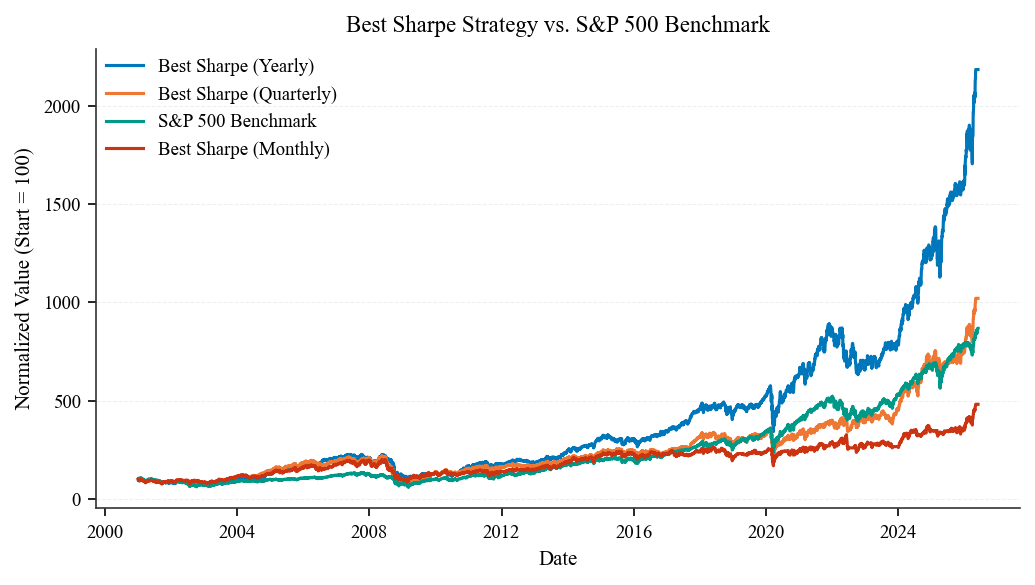

,Best Sharpe (Yearly),Best Sharpe (Quarterly),S&P 500 Benchmark,Best Sharpe (Monthly)
Date,,,,
2001-01-02,100.00000000,100.00000000,100.00000000,100.00000000
2001-01-03,98.36390972,98.36390972,105.02142209,98.36390972
2001-01-04,93.50601108,93.50601108,103.91472269,93.50601108
2001-01-05,93.62272564,93.62272564,101.18705757,93.62272564
2001-01-08,94.61879343,94.61879343,101.01272056,94.61879343
...,...,...,...,...
2026-05-26,2184.42080605,1020.34096343,859.98629693,481.39088079
2026-05-27,2184.42080605,1020.34096343,860.09273034,481.39088079
2026-05-28,2184.42080605,1020.34096343,864.91236499,481.39088079


In [ ]:
portfolio_bs_M = modeling.backtest_portfolio(
    selected_companies=bs_M,
    price_data=merged_data,
    start_date="2001-01-01",
    coverage=coverage,
    missing_ticker=missing_tickers,
    max_abs_return=2.0,
)
portfolio_bs_Q = modeling.backtest_portfolio(
    selected_companies=bs_Q,
    price_data=merged_data,
    start_date="2001-01-01",
    coverage=coverage,
    missing_ticker=missing_tickers,
    max_abs_return=2.0,
)
portfolio_bs_Y = modeling.backtest_portfolio(
    selected_companies=bs_Y,
    price_data=merged_data,
    start_date="2001-01-01",
    coverage=coverage,
    missing_ticker=missing_tickers,
    max_abs_return=2.0,
)

plots.YahooFinance.compare_tickers(
    dfs={
        "Best Sharpe (Monthly)": portfolio_bs_M,
        "Best Sharpe (Quarterly)": portfolio_bs_Q,
        "Best Sharpe (Yearly)": portfolio_bs_Y,
        "Benchmark": benchmark_df
    },
    title="Best Sharpe Strategy vs. S&P 500 Benchmark",
    filename="26-bs-strategy.png",
)

Tym razem to dobór roczny okazał się dużo lepszy niż benchmark. Dobór kwartalny daje wyniki porównywalne z benchmarkiem, natomiast miesięczny ponownie dużo gorzej.

Ponownie - te wyniki strategii również należy brać z ostrożnością. W takim wypadku dobrym pomysłem może okazać się porównanie każdej z tych 3 strategii dla doboru, w którym wszystkie dawały dobre w porównaniu z benchmarkiem zwroty, a więc doboru kwartalnego.

## Porównanie strategii

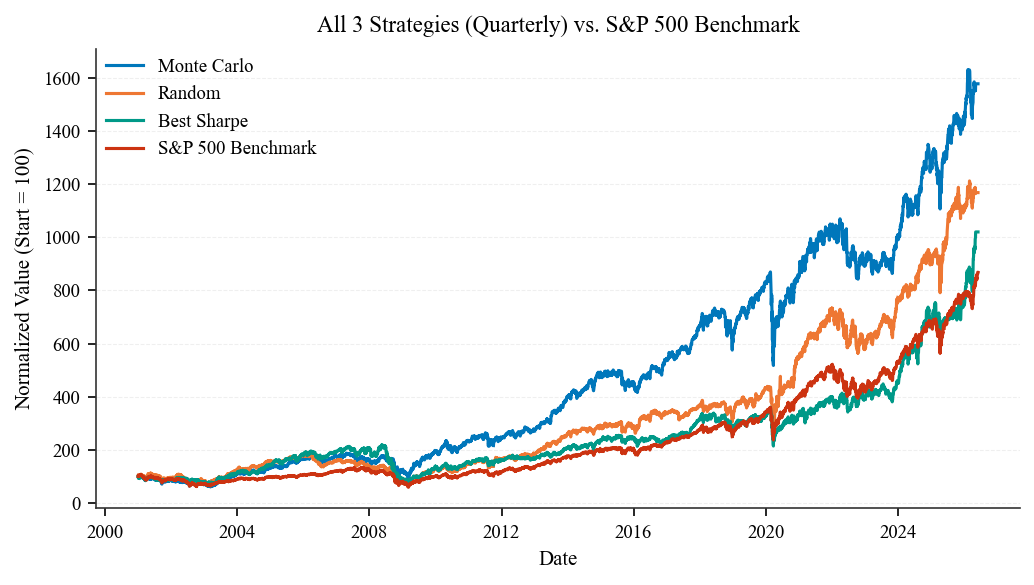

,Monte Carlo,Random,Best Sharpe,S&P 500 Benchmark
Date,,,,
2001-01-02,100.00000000,100.00000000,100.00000000,100.00000000
2001-01-03,102.08751784,106.38738469,98.36390972,105.02142209
2001-01-04,99.42945510,104.20752684,93.50601108,103.91472269
2001-01-05,97.58734245,100.81902244,93.62272564,101.18705757
2001-01-08,97.66898716,101.52242406,94.61879343,101.01272056
...,...,...,...,...
2026-05-26,1577.99730409,1168.41105849,1020.34096343,859.98629693
2026-05-27,1577.99730409,1168.41105849,1020.34096343,860.09273034
2026-05-28,1577.99730409,1168.41105849,1020.34096343,864.91236499


In [ ]:
plots.YahooFinance.compare_tickers(
    dfs={
        "Random": portfolio_random_Q,
        "Monte Carlo": portfolio_mc_Q,
        "Best Sharpe": portfolio_bs_Q,
        "Benchmark": benchmark_df
    },
    title="All 3 Strategies (Quarterly) vs. S&P 500 Benchmark",
    filename="27-strategies-comparision.png",
)

Spośród analizowanych strategii najlepsze wyniki osiągnęła strategia Monte Carlo, której końcowa wartość przekroczyła 1600 (przy wartości początkowej równej 100). Dla porównania strategia losowa osiągnęła około 1200, natomiast strategia najwyższego współczynnika Sharpe'a około 1000. Wszystkie strategie znacząco przewyższyły benchmark, którego końcowa wartość wyniosła około 800. Ze względu na zaskakująco dobre wyniki strategii losowej przy rebalansowaniu kwartalnym, może stanowić ona lepszy punkt odniesienia niż sam benchmark.

Przewagę strategii Monte Carlo bazującej na losowaniu całych portfeli można tłumaczyć korzyściami płynącymi z dywersyfikacji. W tej metodzie spośród wielu losowo wygenerowanych portfeli wybierany jest ten o najwyższym współczynniku Sharpe'a, uwzględniającym zarówno oczekiwaną stopę zwrotu, jak i ryzyko całego portfela. Dzięki temu możliwe jest znalezienie kombinacji spółek, których wzajemne korelacje prowadzą do obniżenia zmienności portfela przy zachowaniu wysokich stóp zwrotu. Z kolei strategia oparta na wyborze N spółek o najwyższym historycznym współczynniku Sharpe'a nie uwzględnia zależności pomiędzy aktywami. Może to skutkować koncentracją portfela w spółkach o podobnym profilu ryzyka lub należących do tych samych sektorów, ograniczając efekty dywersyfikacji i prowadząc do słabszych wyników inwestycyjnych.

In [22]:
all_strategies = {
    "Random (Monthly)": portfolio_random_M,
    "Random (Quarterly)": portfolio_random_Q,
    "Random (Yearly)": portfolio_random_Y,
    "Monte Carlo (Monthly)": portfolio_mc_M,
    "Monte Carlo (Quarterly)": portfolio_mc_Q,
    "Monte Carlo (Yearly)": portfolio_mc_Y,
    "Best Sharpe (Monthly)": portfolio_bs_M,
    "Best Sharpe (Quarterly)": portfolio_bs_Q,
    "Best Sharpe (Yearly)": portfolio_bs_Y,
    "Benchmark": benchmark_df,
}

modeling.calculate_sharpe_ratios(all_strategies)


,strategy,sharpe_ratio
0,Best Sharpe (Yearly),0.65888620
1,Monte Carlo (Quarterly),0.63794698
2,Benchmark,0.56195793
3,Random (Quarterly),0.55324063
4,Monte Carlo (Yearly),0.52851908
5,Best Sharpe (Quarterly),0.52848414
6,Monte Carlo (Monthly),0.40425764
7,Best Sharpe (Monthly),0.40368156
8,Random (Yearly),0.30714900
9,Random (Monthly),0.24850019


Tabela współczynników Sharpe'a rozszerza obraz o pozostałe częstotliwości doboru. Patrząc tylko na dobór kwartalny, Monte Carlo osiąga najwyższy współczynnik Sharpe'a (~0.64) spośród trzech strategii, wyprzedzając strategię losową (~0.55) i strategię najwyższego współczynnika Sharpe'a (~0.53), co jest spójne z wykresem.

W szerszym zestawieniu najwyższy współczynnik Sharpe'a osiąga roczna strategia najwyższego współczynnika Sharpe'a (~0.66), co sugeruje, że ta strategia przy dłuższym horyzoncie rebalansowania lepiej kontroluje ryzyko. Razem z kwartalną strategią Monte Carlo osiąga wynik lepszy od benchmarku. Dobór miesięczny we wszystkich trzech strategiach wypada konsekwentnie najsłabiej, co jest spójne z wcześniejszymi obserwacjami.